# DATA

In [1]:
import numpy as np

npz = np.load("./image_data/O002772.npz")
A = npz["arr_0"]          # 或 npz[npz.files[0]]
print(A.shape, A.dtype)
print(A[:3])              # 看前几行

(115668, 10) float64
[[2.00000000e+00 6.60000000e+01 9.34292749e-02 1.60222620e+03
  7.64792919e-01 8.96666699e+03 7.94200000e+03 8.18966650e+03
  7.56800000e+03 7.43433350e+03]
 [2.00000000e+00 6.70000000e+01 1.57574058e-01 1.70055994e+03
  8.67043972e-01 1.13040000e+04 1.03640000e+04 9.47125000e+03
  8.54350000e+03 8.22650000e+03]
 [2.00000000e+00 6.80000000e+01 9.00644213e-02 1.75546570e+03
  8.71774554e-01 1.06175000e+04 1.03795000e+04 9.76350000e+03
  9.30575000e+03 8.86300000e+03]]


In [ ]:
import numpy as np
from pathlib import Path

src_dir = Path("./data")
dst_dir = Path("./data")
dst_dir.mkdir(parents=True, exist_ok=True)

npz_files = sorted(src_dir.glob("*.npz"))

if len(npz_files) == 0:
    print("No npz files found in", src_dir)
else:
    all_mean_abs = []
    all_max_abs = []
    all_mean_rel = []

    for f in npz_files:
        data = np.load(f)

        # 假设每个 npz 里只有一个主数组；如果有多个键，就逐个处理
        save_dict = {}
        file_mean_abs_list = []
        file_max_abs_list = []
        file_mean_rel_list = []

        for key in data.files:
            arr64 = data[key]

            # 只处理浮点数组；非浮点类型原样保存
            if np.issubdtype(arr64.dtype, np.floating):
                arr32 = arr64.astype(np.float32)

                abs_diff = np.abs(arr64 - arr32.astype(arr64.dtype))
                mean_abs = float(abs_diff.mean())
                max_abs = float(abs_diff.max())

                rel_diff = abs_diff / (np.abs(arr64) + 1e-12)
                mean_rel = float(rel_diff.mean())

                file_mean_abs_list.append(mean_abs)
                file_max_abs_list.append(max_abs)
                file_mean_rel_list.append(mean_rel)

                all_mean_abs.append(mean_abs)
                all_max_abs.append(max_abs)
                all_mean_rel.append(mean_rel)

                save_dict[key] = arr32
            else:
                save_dict[key] = arr64

        out_path = dst_dir / f.name
        np.savez_compressed(out_path, **save_dict)

        if file_mean_abs_list:
            print(f"{f.name}")
            print(f"  mean abs error: {np.mean(file_mean_abs_list):.10g}")
            print(f"  max  abs error: {np.max(file_max_abs_list):.10g}")
            print(f"  mean rel error: {np.mean(file_mean_rel_list):.10g}")
        else:
            print(f"{f.name}")
            print("  no floating-point arrays found, saved without change.")

    if all_mean_abs:
        print("\n=== Overall summary ===")
        print(f"number of files: {len(npz_files)}")
        print(f"overall mean(abs error): {np.mean(all_mean_abs):.10g}")
        print(f"overall max(abs error):  {np.max(all_max_abs):.10g}")
        print(f"overall mean(rel error): {np.mean(all_mean_rel):.10g}")
    else:
        print("\nNo floating-point arrays were found in these npz files.")

# LOSS

Index(['epoch', 'step', 'train_loss_epoch', 'train_loss_step', 'val_loss'], dtype='str')
loss columns: ['train_loss_epoch', 'train_loss_step', 'val_loss']


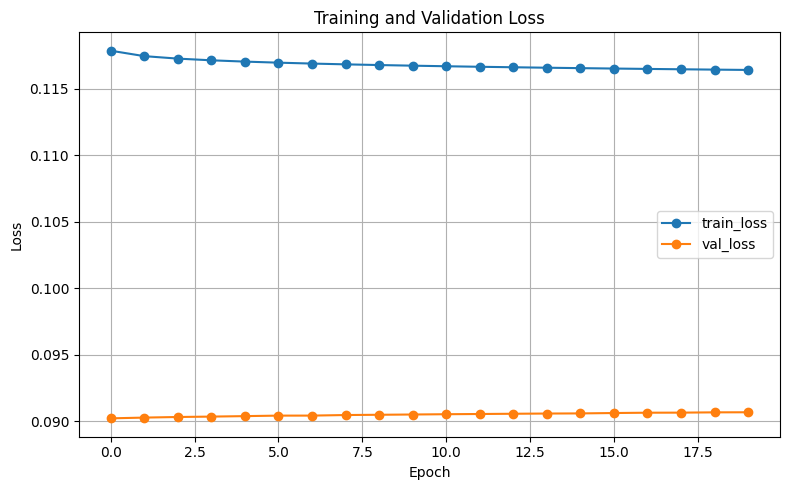

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 改成你实际找到的路径
csv_path = "lightning_logs/version_34/metrics.csv"

df = pd.read_csv(csv_path)
print(df.columns)

# 看看有哪些 loss 列
loss_cols = [c for c in df.columns if "loss" in c.lower()]
print("loss columns:", loss_cols)

# 常见情况：train_loss_epoch / val_loss
plt.figure(figsize=(8, 5))

if "train_loss_epoch" in df.columns:
    train_df = df[["epoch", "train_loss_epoch"]].dropna()
    plt.plot(train_df["epoch"], train_df["train_loss_epoch"], marker="o", label="train_loss")

elif "train_loss" in df.columns:
    train_df = df[["epoch", "train_loss"]].dropna()
    plt.plot(train_df["epoch"], train_df["train_loss"], marker="o", label="train_loss")

if "val_loss" in df.columns:
    val_df = df[["epoch", "val_loss"]].dropna()
    plt.plot(val_df["epoch"], val_df["val_loss"], marker="o", label="val_loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()